## ELFI practice

[ELFI documentation](https://elfi.readthedocs.io/en/latest/), [ELFI tutorial](https://elfi.readthedocs.io/en/latest/usage/tutorial.html)

Local installation:
- `pip3 install elfi`




In [1]:
import time

import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO)  # sometimes this is required to enable logging inside Jupyter

%matplotlib inline
%precision 2

# Set an arbitrary seed and a global random state to keep the randomly generated quantities the same between runs
seed = 20170530  # this will be separately given to ELFI
np.random.seed(seed)

Example simulator: MA(2)

$$y_t = w_t + \theta_1w_{t-1} + \theta_2w_{t-2},$$ where $\theta_1, \theta_2 \in \mathbb{R}$ and the weights are white noise (iid $N(0,1)$)


In [2]:
def MA2(t1,t2, n_obs=100, batch_size=1, random_state=None): # this is the thing I would need to define myself.
    t1 = np.asanyarray(t1).reshape((-1, 1))
    t2 = np.asanyarray(t2).reshape((-1, 1))
    random_state = random_state or np.random

    w = random_state.randn(batch_size, n_obs+2)  # i.i.d. sequence ~ N(0,1)
    x = w[:, 2:] + t1*w[:, 1:-1] + t2*w[:, :-2]
    return x


# batch_size, random_state are for ELFI
# random_state is very important - remember to have it!

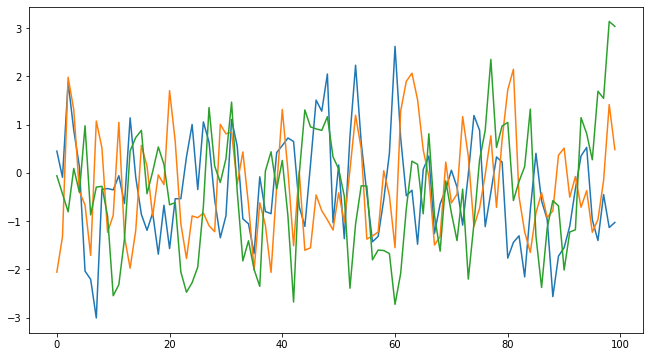

In [3]:
# choose true parameters
t1_true = 0.6
t2_true = 0.2

y_obs = MA2(t1_true, t2_true)

# Plot the observed sequence
plt.figure(figsize=(11, 6));
plt.plot(y_obs.ravel());

# To illustrate the stochasticity, let's plot a couple of more observations with the same true parameters:
plt.plot(MA2(t1_true, t2_true).ravel());
plt.plot(MA2(t1_true, t2_true).ravel());


### ABC, approximate bayesian computation
- Motivation: irl hidden variables, infeasible likelihoods & unobtainable likelihoods.
- ABC solution: replace the likelihood with a simulator of the data. Keep simulating, until the sequences are close to the data. These params then intuitively are close to the true parameters that produced the data.

In [4]:
import elfi
import graphviz

t1 = elfi.Prior(scipy.stats.uniform, 0, 2)
t2 = elfi.Prior("uniform", 0, 2)

Y = elfi.Simulator(MA2, t1, t2, observed = y_obs) # input the previous "observed" data

# How to compare the simulated sequences to the data? This is the most difficult thing about ABC.

def autocov(x, lag=1): # autocovariance. Related to the intuition of MA2 process.
    C = np.mean(x[:,lag:] * x[:,:-lag], axis=1)
    return C

S1 = elfi.Summary(autocov, Y)
S2 = elfi.Summary(autocov, Y, 2)  # the optional keyword lag is given the value 2

# choose discrepancy
# Finish the model with the final node that calculates the squared distance (S1_sim-S1_obs)**2 + (S2_sim-S2_obs)**2
d = elfi.Distance('euclidean', S1, S2)

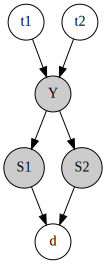

In [5]:
elfi.draw(d.model)  # just give it a node in the model, or the model itself (d.model)

Installation of graphviz locally (Ubuntu)
- `pkcon install graphviz`
- `pip3 install graphviz`

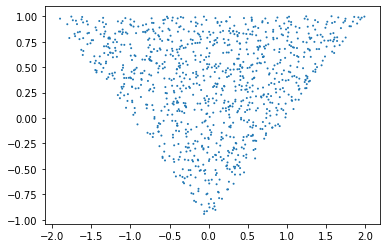

In [6]:
# Priors according to Marin et al 2012

# define prior for t1 as in Marin et al., 2012 with t1 in range [-b, b]
class CustomPrior_t1(elfi.Distribution):
    def rvs(b, size=1, random_state=None):
        u = scipy.stats.uniform.rvs(loc=0, scale=1, size=size, random_state=random_state)
        t1 = np.where(u<0.5, np.sqrt(2.*u)*b-b, -np.sqrt(2.*(1.-u))*b+b)
        return t1

# define prior for t2 conditionally on t1 as in Marin et al., 2012, in range [-a, a]
class CustomPrior_t2(elfi.Distribution):
    def rvs(t1, a, size=1, random_state=None):
        locs = np.maximum(-a-t1, t1-a)
        scales = a - locs
        t2 = scipy.stats.uniform.rvs(loc=locs, scale=scales, size=size, random_state=random_state)
        return t2
    

t1_1000 = CustomPrior_t1.rvs(2, 1000)
t2_1000 = CustomPrior_t2.rvs(t1_1000, 1, 1000)
plt.scatter(t1_1000, t2_1000, s=4, edgecolor='none');


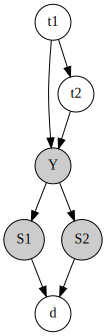

In [7]:
# change the priors to new ones:
t1.become(elfi.Prior(CustomPrior_t1, 2))
t2.become(elfi.Prior(CustomPrior_t2, t1, 1))

elfi.draw(d.model) # hmm the pretty graph does not update. Probably because Ubuntu :)

### Inference with rejection sampling

Simulate, compare simulated with observed, if distance too high, reject.
- batch_size: how many simulations performed in each passing through the graph


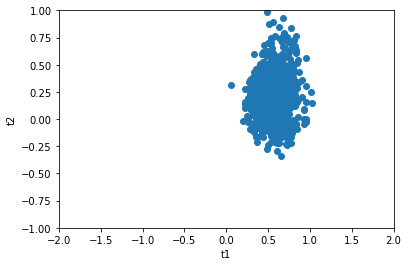

Progress [==================================================] 100.0% Complete
CPU times: user 2.05 s, sys: 104 ms, total: 2.15 s
Wall time: 2.21 s


In [8]:
rej = elfi.Rejection(d, batch_size=10000, seed=seed)

N = 1000

vis = dict(xlim=[-2,2], ylim=[-1,1])

# You can give the sample method a `vis` keyword to see an animation how the prior transforms towards the
# posterior with a decreasing threshold.
%time result = rej.sample(N, quantile=0.01, vis=vis)

In [9]:
print(result.samples['t1'].mean())
print(result.samples['t2'].mean())

result.summary()


0.5560091548387966
0.21858256816520824
Method: Rejection
Number of samples: 1000
Number of simulations: 100000
Threshold: 0.117
Parameter                Mean               2.5%              97.5%
t1:                     0.556              0.297              0.835
t2:                     0.219             -0.151              0.664



In [10]:
# using a threshold: everything from the prior below this will be accepted as samples
%time result2 = rej.sample(N, threshold=0.2)

print(result2)  # the Sample object's __str__ contains the output from summary()

CPU times: user 175 ms, sys: 16.4 ms, total: 191 ms---------] 75.0% Complete
Wall time: 190 ms
Method: Rejection
Number of samples: 1000
Number of simulations: 40000
Threshold: 0.185
Parameter                Mean               2.5%              97.5%
t1:                     0.555              0.268              0.883
t2:                     0.223             -0.167              0.672




# Part II: Models for transmission dynamics


In [ ]:
import numpy as np


ts = np.arange(0,100,1)
params = {"beta":0.5, "gamma":0.2, "N":100}
initial = {"S":99, "I":1, "R":0}
print(len(ts))

def SIR(y, params):
    
    dS = -params["beta"]*y["S"]*y["I"]/params["N"]
    dI = params["beta"]*y["S"]*y["I"]/params["N"] - params["gamma"]*y["I"]
    dR = params["gamma"]*y["I"]
    
    
    return [dS, dI, dR]

def step(delta_t, y0, params):
    
    d = SIR(y0, params)
    
    y1 = {"S": y0["S"] + d[0]*delta_t, "I":y0["I"] + d[1]*delta_t,\
          "R":y0["R"] + d[2]*delta_t}
    
    return y1

# test

SIR(initial, params)
step(1, initial, params)

In [ ]:
# iterate

S = []
I = []
R = []
y0 = initial
delta_t = 1 # step one day at a time

for t in ts:
    
    y1 = step(delta_t, y0, params)
    
    S.append(y1["S"])
    I.append(y1["I"])
    R.append(y1["R"])
    
    y0 = y1
    

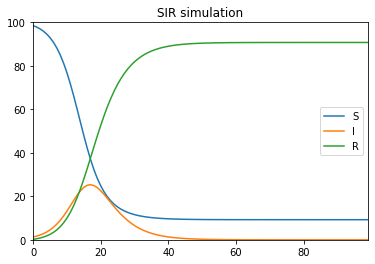

In [27]:
import matplotlib.pyplot as plt
plt.axis([0, max(ts), 0, params["N"]])

plt.plot(ts, S)
plt.plot(ts, I)
plt.plot(ts, R)
plt.title("SIR simulation")
plt.legend(["S", "I", "R"])
plt.show()

### Frequentist methods for estimating target parameters from data


Check [Tang et al 2020](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7436714/).


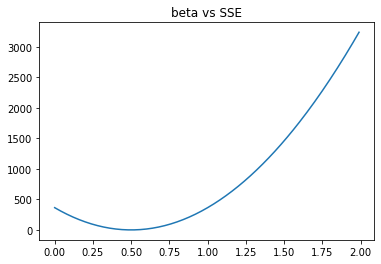

In [70]:
betas = []
losses = []
ts = np.arange(0,1000,1)
initial = {"S":99, "I":1, "R":0}
true_params = {"beta":0.5, "gamma":0.2, "N":100}

for beta in np.arange(0,2,0.01):
    
    I_obs = []
    I_hat = []
    y0_true = initial
    y0_hat = initial
    
    for t in ts:
        
        y1_true = step(1, y0_true, true_params)
        y1_hat = step(1, y0_hat, {"beta":beta, "gamma":0.2, "N":100})
    
        I_obs.append(y1_true["I"])
        I_hat.append(y1_hat["I"])
        
        y0_true = y1_true
        y0_hat = y0_true
        
    # compute loss
    loss = np.sum((np.array(I_hat) - np.array(I_obs))**2)
    losses.append(loss)
    betas.append(beta)

    
plt.plot(betas, losses)
#plt.axvline(x = 0.5, color = 'r')
plt.title("beta vs SSE")
plt.show()

# there might be something fishy going on here, since the loss is not the same as in the article example. 
# Shape is similar though.